# Introduction to Kalmand and Particle filters for Object Tracking


Object tracking is a crucial task in computer vision and robotics. Imagine following an object in a video stream or predicting the path of an airplane. This is challenging as sensors, such as camera or GPS, are often noisy or incomplete. One way to get a better estimate of the object's state, like its position and velocity, is to combine these uncertain measurements. This is where filtering plays its role. Filters are mathematical tools that help to estimate hidden state of a system based on a sequence of noisy inputs. Here we present a few fundamental filtering techniques.

## State estimation

The state of an object is a set of variables that describe its condition at a particular time step. For a moving object, the state might have following elements:

*   **Position** - Where is the object, e.g. x, y coordinates
*   **Velocity** - How fast and in what direction the object is moving, e.g. vx, vy
*   **Acceleration** - Is the object speeding up or slowing down, e.g. ax, ay

The goal of object tracking is **state estimation**, that is estimating the most likely values for these state variables, even though they cannot be measured directly and precisely.

## 1. G-H Filter (Alpha-Beta Filter)

The g-h filter is one of the simplest filtering algorithms. It introduces the core idea of prediction and correction that can be found in more advanced techniques.

Let's take a moving train on a straight track as an example. We only care about its position and velocity. The algorithm can be expressed as foolows:

1.  **Predict** - Based on the last known posittion and velocity, predict where the train will be next.
    *   `pred_pos = last_pos + (last_vel * time_step)`
    *   `pred_vel = last_vet` (assuming constant velocity for simplicity)
2.  **Measure** - Get a new measurement of the train's position, e.g. from a sensor. This measurement will introduce some noise.
3.  **Update** - Compare the predicted position with the measured position. The difference is the error. Use this error to correct both the position and velocity esimates.
    *   The `g` parameter controls how much we adjust the position based on the measurement error.
    *   The `h` parameter control how much we adjust the velocity based on the measurement error.
    *   `corr_pos = pred_pos + g * (m_pos - pred_pos)`
    *   `corr_vel = pred_vel + h * (m_pos - pred_pos) / time_step`

The g-h filter works well in simple scenarios but relies heavily on correctly set 'g' and 'h' parameters. Additionally, it assumes a relatively simple motion model.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def gh_filter(data, x0, dx, g, h, dt):
    x_est = x0
    dx_est = dx
    estimates = []

    for z in data:
        # Prediction step
        x_pred = x_est + (dx_est * dt)
        dx_pred = dx_est

        # Update step
        residual = z - x_pred
        dx_est = dx_pred + h * (residual / dt)
        x_est = x_pred + g * residual

        estimates.append(x_est)

    return np.array(estimates)

In [3]:
# True state
true_velocity = 2.0
initial_pos = 0.0
dt = 1.0 # time step
num_steps = 20
time = np.arange(0, num_steps*dt, dt)
true_positions = initial_pos + true_velocity * time

In [4]:
# Measurements (true position + noise)
measurement_noise_std = 5.0
measurements = true_positions + np.random.normal(0, measurement_noise_std, size=num_steps)

In [5]:
g = 0.2 # Position adjustment factor
h = 0.02 # Velocity adjustment factor

# Initial guesses
initial_pos_guess = measurements[0]
initial_vel_guess = 0.0

estimated_positions = gh_filter(
    data=measurements,
    x0=initial_pos_guess,
    dx=initial_vel_guess,
    g=g,
    h=h,
    dt=dt
)

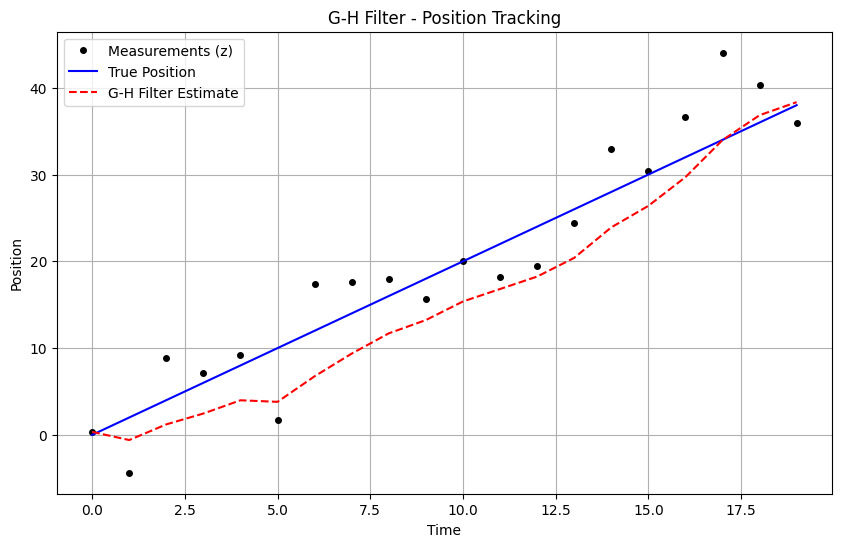

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(time, measurements, 'ko', markersize=4, label='Measurements (z)')
plt.plot(time, true_positions, 'b-', label='True Position')
plt.plot(time, estimated_positions, 'r--', label='G-H Filter Estimate')
plt.xlabel('Time')
plt.ylabel('Position')
plt.title('G-H Filter - Position Tracking')
plt.legend()
plt.grid(True)

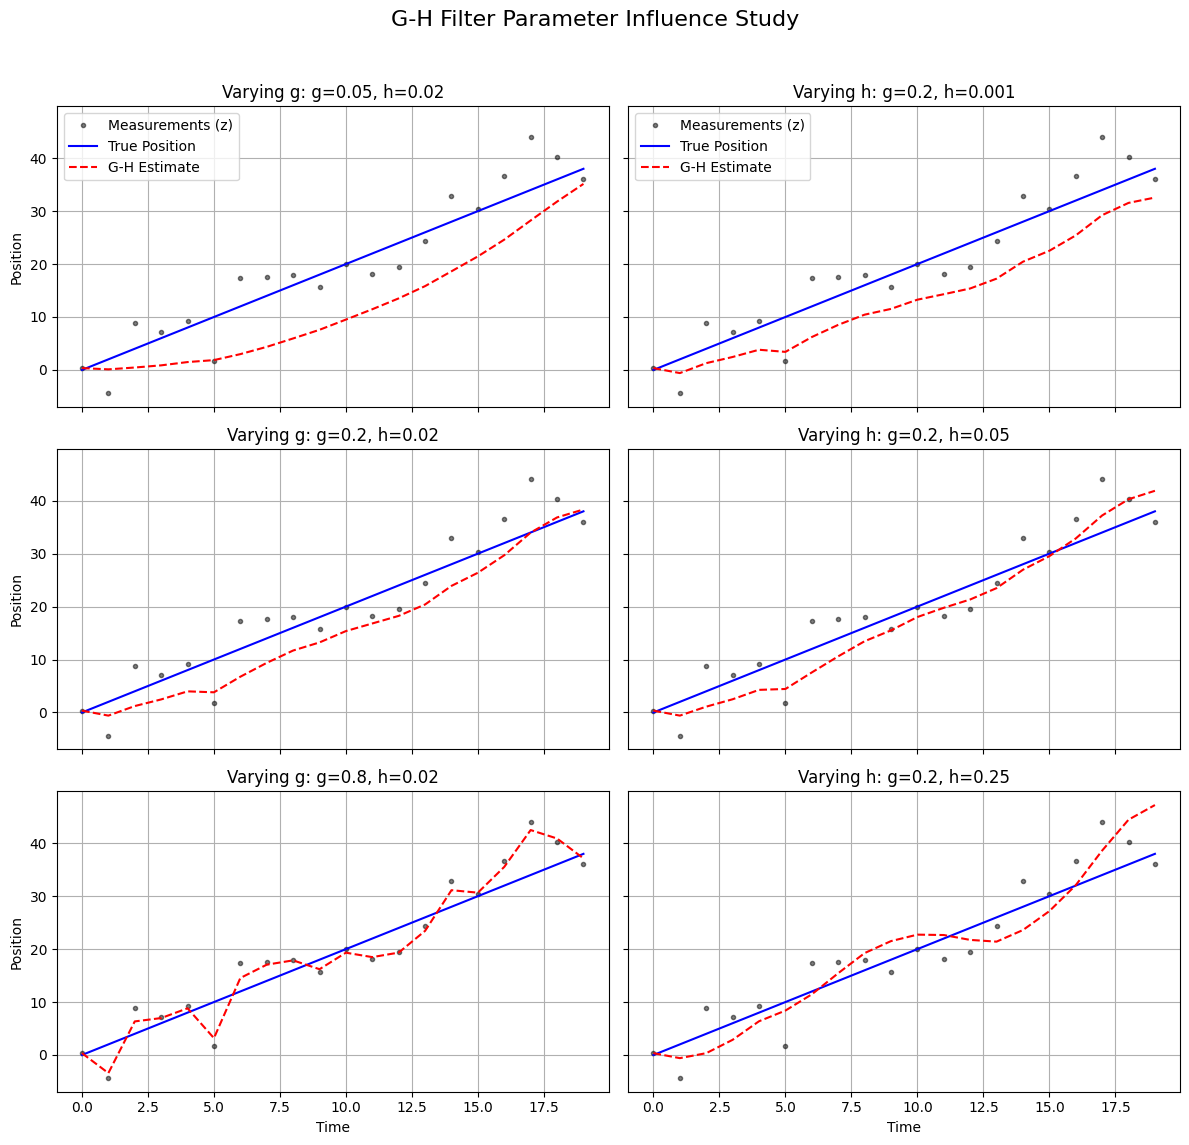

In [7]:
g_values = [0.05, 0.2, 0.8]  # Low, Medium, High g
h_values = [0.001, 0.05, 0.25] # Low, Medium, High h

fixed_g = 0.2  # Use medium g when varying h
fixed_h = 0.02 # Use medium h when varying g

fig, axes = plt.subplots(3, 2, figsize=(12, 12), sharex=True, sharey=True)
fig.suptitle('G-H Filter Parameter Influence Study', fontsize=16)

# Column 1: Varying g, fixed h
for i, g_val in enumerate(g_values):
    estimated_positions = gh_filter(
        data=measurements,
        x0=initial_pos_guess,
        dx=initial_vel_guess,
        g=g_val,
        h=fixed_h,
        dt=dt
    )
    ax = axes[i, 0]
    ax.plot(time, measurements, 'ko', markersize=3, alpha=0.5, label='Measurements (z)')
    ax.plot(time, true_positions, 'b-', linewidth=1.5, label='True Position')
    ax.plot(time, estimated_positions, 'r--', linewidth=1.5, label='G-H Estimate')
    ax.set_title(f'Varying g: g={g_val}, h={fixed_h}')
    ax.grid(True)
    if i == 0:
        ax.legend()
    if i == 2:
        ax.set_xlabel('Time')
    ax.set_ylabel('Position')


# Column 2: Varying h, fixed g
for i, h_val in enumerate(h_values):
    estimated_positions = gh_filter(
        data=measurements,
        x0=initial_pos_guess,
        dx=initial_vel_guess,
        g=fixed_g,
        h=h_val,
        dt=dt
    )
    ax = axes[i, 1]
    ax.plot(time, measurements, 'ko', markersize=3, alpha=0.5, label='Measurements (z)')
    ax.plot(time, true_positions, 'b-', linewidth=1.5, label='True Position')
    ax.plot(time, estimated_positions, 'r--', linewidth=1.5, label='G-H Estimate')
    ax.set_title(f'Varying h: g={fixed_g}, h={h_val}')
    ax.grid(True)
    if i == 0:
        ax.legend()
    if i == 2:
        ax.set_xlabel('Time')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

* Varying g (Column 1):
    *   **Low g** - The estimate is very smooth but lags behind the true position
    *   **Medium g** - A balance between smoothing and responsiveness
    *   **High g** - The estimate follows the measurements very closely

* Varying h (Column 2):
    *   **Low h** - The velocity esimate changes very slowly
    *   **Medium h** - A balanced velocity update
    *   **High h** - The velocity estimate changes rapidly based on position error

## 2. The Discrete Bayes Filter

While the g-h filter gives a single best guess, the bayes filter provides a probabilistic approach. Instead of tracking a single value, it maintains a probability distribution over all possible states.

1.  **Predict** - Take the current probability distribution of the state and predict how it will evolve over time based on how we think the object moves.
2.  **Update** - Use the latest measurement to update the predicted probability distribution. States that are more consistent with the measurements become more likely, while inconsistent states become less likely.

The Discrete Bayes Filter is a specific algorithm where the state space is divided into finite number of bins or grid cells. It maintains the probability if the object in each cell. This can represent arbitraty probability distributions, however, it can become computationally expensive if the state space is large (curse of dimensionality).

In [8]:
def predict(belief, kernel):
    return np.convolve(belief, kernel, mode='same')

def update(belief, measurement, likelihood_fn):
    likelihood = likelihood_fn(measurement, np.arange(len(belief)))
    posterior_unnormalized = belief * likelihood

    # Normalize the posterior distribution
    norm = np.sum(posterior_unnormalized)
    if norm > 1e-9: # Avoid division by zero
        return posterior_unnormalized / norm
    else:
        return posterior_unnormalized

def compute_likelihood(measurement, states, z_prob):
    """
    Simplified likelihood calculation for each possible state.
    """
    N = len(states)
    likelihood = np.zeros(N)
    for x in states:
        # Calculate distance in circular world
        diff = abs(measurement - x)
        dist = min(diff, N - diff)

        if dist == 0:
            likelihood[x] = z_prob
        elif dist == 1:
             likelihood[x] = (1.0-z_prob)/2.0  # Simplified: only adjacent noise
        else:
             likelihood[x] = 0.0  # Simplified: zero probability elsewhere

    return likelihood

In [9]:
world_size = 20         # Number of discrete locations/states
num_steps = 50          # Number of simulation steps
initial_pos = 5         # True starting position
move_step = 1 

In [10]:
move_kernel = np.array([0.1, 0.8, 0.1])  # 10 % chance to move left, 80 % chance to stay, 10 % chance to move right

In [11]:
measurement_correct_prob = 0.7

In [12]:
belief = np.ones(world_size) / world_size  # uniform probability
true_state = initial_pos

belief_history = [belief]
true_state_history = [true_state]
measurement_history = []

In [13]:
for t in range(num_steps):
    # 1. Simulate True Movement
    move_options = [-1, 0, 1] # Relative moves possible
    actual_move = np.random.choice(move_options, p=move_kernel)
    true_state = (true_state + actual_move) % world_size # Circular world
    true_state_history.append(true_state)

    # 2. Simulate Measurement
    measurement_likelihoods = compute_likelihood(true_state, np.arange(world_size), measurement_correct_prob)
    # Sample a measurement based on these likelihoods
    measurement_likelihoods_norm = measurement_likelihoods / np.sum(measurement_likelihoods)
    if np.sum(measurement_likelihoods) < 1e-9:
         measurement = true_state
    else:
        measurement = np.random.choice(np.arange(world_size), p=measurement_likelihoods_norm)

    measurement_history.append(measurement)

    # 3. Predict Step
    belief_prior = predict(belief, move_kernel)

    # 4. Update Step
    belief = update(belief_prior, measurement,
                    lambda z, states: compute_likelihood(z, states, measurement_correct_prob))

    belief_history.append(belief)

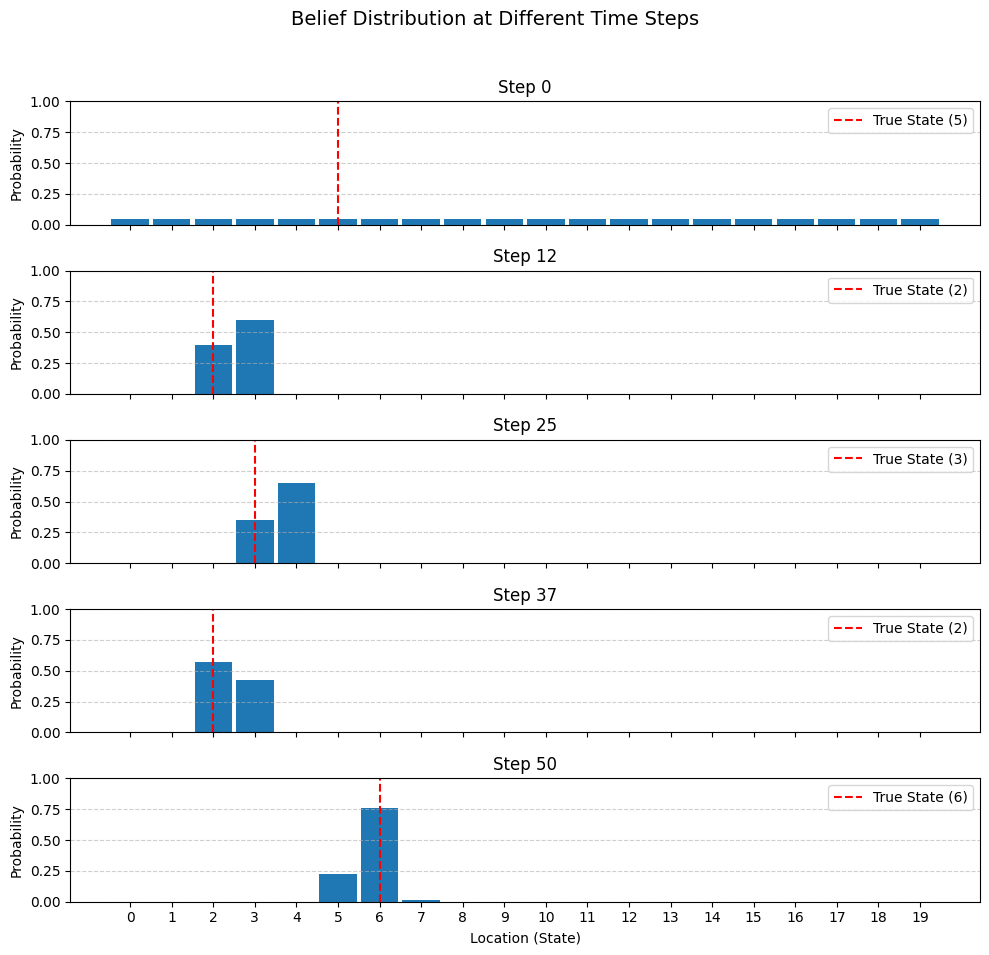

In [14]:
steps_to_plot = [0, num_steps // 4, num_steps // 2, 3 * num_steps // 4, num_steps]

fig_hist, axes_hist = plt.subplots(len(steps_to_plot), 1, figsize=(10, 2 * len(steps_to_plot)), sharex=True)
fig_hist.suptitle('Belief Distribution at Different Time Steps', fontsize=14)

for i, step in enumerate(steps_to_plot):
    ax = axes_hist[i]
    belief_at_step = belief_history[step]
    true_state_at_step = true_state_history[step]

    ax.bar(np.arange(world_size), belief_at_step, width=0.9)
    ax.axvline(true_state_at_step, color='r', linestyle='--', label=f'True State ({true_state_at_step})')
    ax.set_title(f'Step {step}')
    ax.set_ylabel('Probability')
    ax.grid(True, axis='y', linestyle='--', alpha=0.6)
    ax.legend(loc='upper right')
    ax.set_ylim(0, 1.0)


axes_hist[-1].set_xlabel('Location (State)')
plt.xticks(np.arange(world_size))
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()